Piriyadharshini N 24BAD086
EXP 9

--- DATA HEAD ---
   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  

--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836

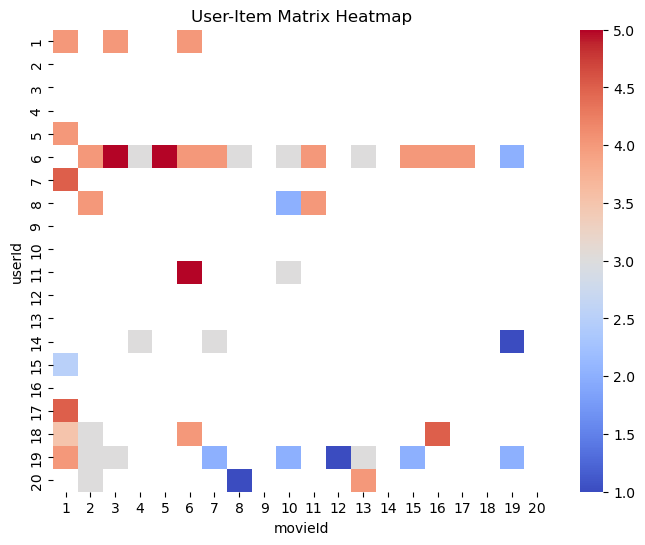

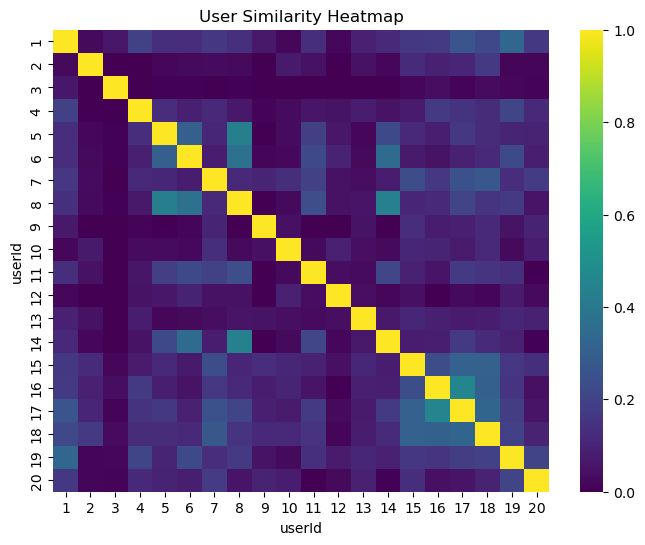

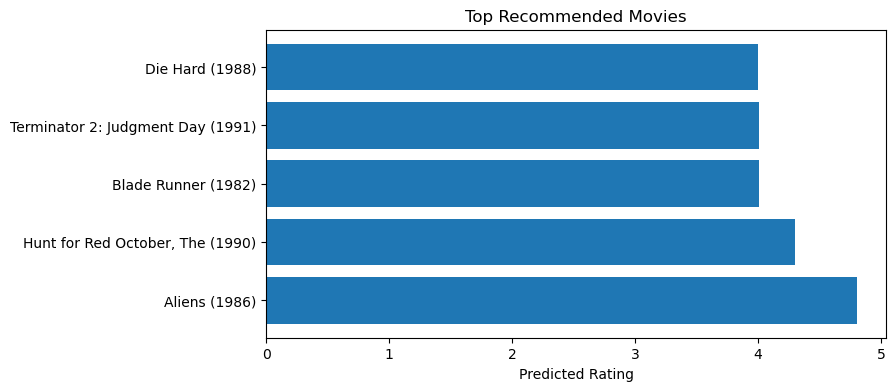

In [6]:
print("Piriyadharshini N 24BAD086\nEXP 9")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

print("\n--- DATA HEAD ---")
print(data.head())

print("\n--- DATA INFO ---")
print(data.info())

print("\n--- MISSING VALUES ---")
print(data.isnull().sum())

print("\nUsers:", data.userId.nunique())
print("Movies:", data.movieId.nunique())

user_item_matrix = data.pivot(index="userId", columns="movieId", values="rating")

user_item_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

print("\n--- Similar Users for User 1 ---")
print(get_similar_users(1))

def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, 5)

    sim_scores = similar_users.values
    sim_users = similar_users.index

    weighted_sum = user_item_filled.loc[sim_users].T.dot(sim_scores)
    sim_total = np.sum(sim_scores)

    predictions = weighted_sum / sim_total
    return predictions

def recommend_movies(user_id, n=5):
    predictions = predict_ratings(user_id)

    watched = user_item_matrix.loc[user_id].dropna().index
    recommendations = predictions.drop(watched)

    top = recommendations.sort_values(ascending=False).head(n)

    result = pd.merge(top.reset_index(),
                      movies,
                      on="movieId")[["title", 0]]

    result.columns = ["Movie", "Predicted Rating"]
    return result

print("\n--- Top Recommendations for User 1 ---")
rec = recommend_movies(1)
print(rec)

train, test = train_test_split(data, test_size=0.2, random_state=42)

# Create pivot tables
train_matrix = train.pivot(index="userId", columns="movieId", values="rating")
test_matrix = test.pivot(index="userId", columns="movieId", values="rating")

# Align both matrices
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=1)

# Fill missing values
train_matrix = train_matrix.fillna(0)
test_matrix = test_matrix.fillna(0)

# Compute similarity
similarity = cosine_similarity(train_matrix)

# Prediction
pred = similarity.dot(train_matrix) / np.array([np.abs(similarity).sum(axis=1)]).T

# Convert to DataFrame 
pred_df = pd.DataFrame(pred,
                       index=train_matrix.index,
                       columns=train_matrix.columns)

# Evaluate only where test ratings exist
mask = test_matrix > 0

pred_flat = pred_df[mask]
test_flat = test_matrix[mask]

# Drop NaN values
pred_flat = pred_flat.values.flatten()
test_flat = test_flat.values.flatten()

valid_idx = ~np.isnan(test_flat)
pred_flat = pred_flat[valid_idx]
test_flat = test_flat[valid_idx]

# Metrics
rmse = np.sqrt(mean_squared_error(test_flat, pred_flat))
mae = mean_absolute_error(test_flat, pred_flat)

print("\n--- FIXED MODEL EVALUATION ---")
print("RMSE:", rmse)
print("MAE:", mae)


# Sparsity
sparsity = 1 - (user_item_matrix.count().sum() /
               (user_item_matrix.shape[0] * user_item_matrix.shape[1]))

print("\n--- ANALYSIS ---")
print("Sparsity of matrix:", sparsity)


# Heatmap - User Item
plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap="coolwarm")
plt.title("User-Item Matrix Heatmap")
plt.show()

# Heatmap - Similarity
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("User Similarity Heatmap")
plt.show()

# Top Recommendations Graph
plt.figure(figsize=(8,4))
plt.barh(rec["Movie"], rec["Predicted Rating"])
plt.title("Top Recommended Movies")
plt.xlabel("Predicted Rating")
plt.show()

Piriyadharshini N 24BAD086
EXP 9

--- Similar Items to Movie ID 1 ---
                                       title         1
0                         Toy Story 2 (1999)  0.572601
1                       Jurassic Park (1993)  0.565637
2       Independence Day (a.k.a. ID4) (1996)  0.564262
3  Star Wars: Episode IV - A New Hope (1977)  0.557388
4                        Forrest Gump (1994)  0.547096

--- Item-Based Recommendations for User 1 ---
                             title         0
0  Ferris Bueller's Day Off (1986)  0.348158
1                  Die Hard (1988)  0.326703
2       Breakfast Club, The (1985)  0.323969
3        Fifth Element, The (1997)  0.322248
4                    Aliens (1986)  0.318971


C:\Users\piriyadharshini\AppData\Local\Temp\ipykernel_21512\894473062.py:80: RuntimeWarning: invalid value encountered in divide
  pred = similarity.dot(train_matrix) / np.array([np.abs(similarity).sum(axis=1)]).T



--- FIXED RMSE ---
RMSE: 3.376997074200516

Precision@5 for User 1: 0.0

--- Popular Movies ---
movieId
356     329
318     317
296     307
593     279
2571    278
Name: rating, dtype: int64

--- Niche Movies ---
movieId
193609    1
4032      1
57526     1
57522     1
57502     1
Name: rating, dtype: int64


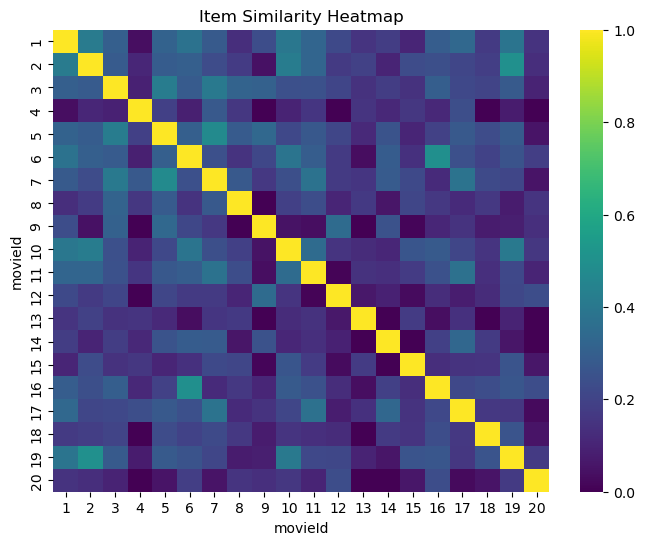

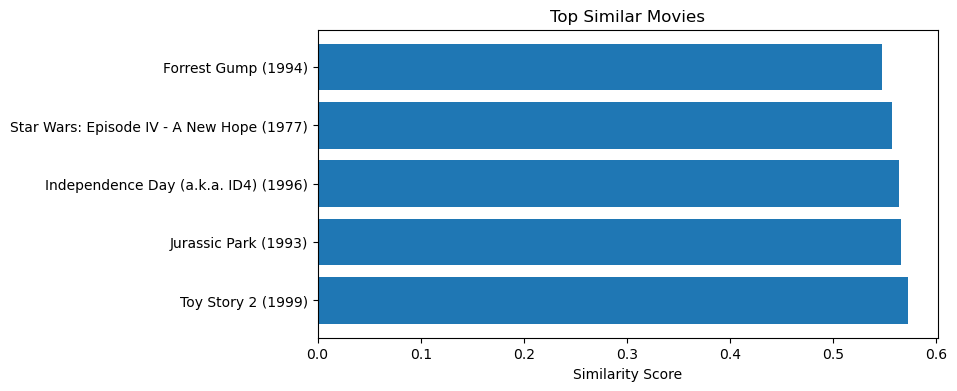

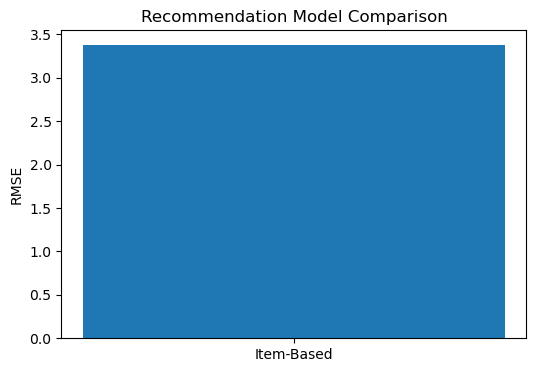

In [7]:
print("Piriyadharshini N 24BAD086\nEXP 9")
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

data = pd.merge(ratings, movies, on="movieId")

item_user_matrix = data.pivot(index="movieId", columns="userId", values="rating")

# Fill missing values
item_user_filled = item_user_matrix.fillna(0)

item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

def get_similar_items(movie_id, n=5):
    similar = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    return pd.merge(similar.reset_index(),
                    movies,
                    on="movieId")[["title", movie_id]]

print("\n--- Similar Items to Movie ID 1 ---")
print(get_similar_items(1))

# First create user-item matrix
user_item_matrix = data.pivot(index="userId", columns="movieId", values="rating")

def item_based_recommend(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id].dropna()

    scores = pd.Series(dtype=float)

    for movie, rating in user_ratings.items():
        sim_scores = item_similarity_df[movie]
        scores = scores.add(sim_scores * rating, fill_value=0)

    scores = scores / user_ratings.sum()

    watched = user_ratings.index
    recommendations = scores.drop(watched)

    top = recommendations.sort_values(ascending=False).head(n)

    return pd.merge(top.reset_index(),
                    movies,
                    on="movieId")[["title", 0]]

print("\n--- Item-Based Recommendations for User 1 ---")
rec_item = item_based_recommend(1)
print(rec_item)

train, test = train_test_split(data, test_size=0.2, random_state=42)

# Pivot
train_matrix = train.pivot(index="movieId", columns="userId", values="rating")
test_matrix = test.pivot(index="movieId", columns="userId", values="rating")

# Align BOTH axes (rows + columns)
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=0)
train_matrix, test_matrix = train_matrix.align(test_matrix, join='outer', axis=1)

# Fill missing
train_matrix = train_matrix.fillna(0)
test_matrix = test_matrix.fillna(0)

# Similarity
similarity = cosine_similarity(train_matrix)

# Prediction
pred = similarity.dot(train_matrix) / np.array([np.abs(similarity).sum(axis=1)]).T

pred_df = pd.DataFrame(pred,
                       index=train_matrix.index,
                       columns=train_matrix.columns)


# Stack to long format 
pred_long = pred_df.stack().reset_index()
pred_long.columns = ["movieId", "userId", "pred_rating"]

test_long = test_matrix.stack().reset_index()
test_long.columns = ["movieId", "userId", "true_rating"]

# Merge predictions with actuals
eval_df = pd.merge(test_long, pred_long,
                   on=["movieId", "userId"])

# Keep only actual ratings 
eval_df = eval_df[eval_df["true_rating"] > 0]

# Metrics
rmse = np.sqrt(mean_squared_error(eval_df["true_rating"],
                                  eval_df["pred_rating"]))

print("\n--- FIXED RMSE ---")
print("RMSE:", rmse)

def precision_at_k(user_id, k=5):
    recommended = item_based_recommend(user_id, k)["title"].values

    relevant = data[(data.userId == user_id) & (data.rating >= 4)]["movieId"]
    relevant_titles = movies[movies.movieId.isin(relevant)]["title"].values

    hits = sum([1 for movie in recommended if movie in relevant_titles])
    return hits / k

print("\nPrecision@5 for User 1:", precision_at_k(1, 5))


# Popular vs Niche
popularity = data.groupby("movieId")["rating"].count()

print("\n--- Popular Movies ---")
print(popularity.sort_values(ascending=False).head())

print("\n--- Niche Movies ---")
print(popularity.sort_values().head())


# Item Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap="viridis")
plt.title("Item Similarity Heatmap")
plt.show()

# Top Similar Items Graph
similar_items = get_similar_items(1)

plt.figure(figsize=(8,4))
plt.barh(similar_items["title"], similar_items[1])
plt.title("Top Similar Movies")
plt.xlabel("Similarity Score")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Item-Based"], [rmse])
plt.title("Recommendation Model Comparison")
plt.ylabel("RMSE")
plt.show()